# Demo 5 — Small Data, Strong Prior

### Chapter 5 of the open tabular stack: *the prior is everything*

> **When data is scarce, the prior is everything. Foundation models bring a free one.**

Below ~150 rows, gradient boosting collapses — there's not enough signal to fit anything useful. TabICL's pre-training on millions of synthetic tables means it shows up to the small-data fight already knowing how tabular data behaves.

| Sweep parameter | Value |
|---|---|
| Train sizes | `[50, 100, 200, 350, 500]` |
| Random repeats | `3` (seeds 0, 1, 2) |
| Test set | held-out, fixed, `n=100` |
| Models | HGBT (gray) vs. TabICL (orange) |
| Metric | ROC AUC |

Money line: clinical trials, manufacturing defect data, rare-event modeling — anywhere collecting more rows is expensive.

In [1]:
import os
from pathlib import Path

# Load SKORE_HUB_API_KEY from .env at the repo root.
_repo_root = Path.cwd()
while not (_repo_root / ".env").exists() and _repo_root != _repo_root.parent:
    _repo_root = _repo_root.parent
_env_path = _repo_root / ".env"
if _env_path.exists():
    for _line in _env_path.read_text().splitlines():
        _line = _line.strip()
        if _line and not _line.startswith("#") and "=" in _line:
            _k, _v = _line.split("=", 1)
            os.environ.setdefault(_k.strip(), _v.strip().strip('"'))

import skore
if "SKORE_HUB_API_KEY" in os.environ:
    skore.login()


╭───────────────────────────────── Login to Skore Hub ─────────────────────────────────╮
│                                                                                      │
│                        Successfully logged in, using API key.                        │
│                                                                                      │
╰──────────────────────────────────────────────────────────────────────────────────────╯

In [2]:
import time
import warnings
from pathlib import Path

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.pipeline import make_pipeline
from sklearn.metrics import roc_auc_score
from skrub import TableVectorizer
from tabicl import TabICLClassifier
import skore

plt.rcParams["figure.dpi"] = 110

# Probabl brand palette
BLUE = "#1E22AA"
ORANGE = "#F68D2E"
GRAY = "#94A3B8"
DARK = "#1A1A2E"

## 1. Data — breast cancer

569 rows, binary, fully numeric. We hold out a fixed test set of 100 rows and **sub-sample** the training pool to simulate small-data regimes.

In [3]:
data = load_breast_cancer(as_frame=True)
X, y = data.data, data.target.astype(int)

# Fixed held-out test set of size 100
X_pool, X_test, y_pool, y_test = train_test_split(
    X, y, test_size=100, stratify=y, random_state=42
)

print(f"Full dataset: {X.shape}")
print(f"Training pool: {X_pool.shape}  |  Test set: {X_test.shape}")
print(f"Class balance (pool): {y_pool.value_counts(normalize=True).round(3).to_dict()}")

Full dataset: (569, 30)
Training pool: (469, 30)  |  Test set: (100, 30)
Class balance (pool): {1: 0.627, 0: 0.373}


## 2. Sweep: 50 → 500

For each train size and each model, three stratified sub-samples (seeds 0, 1, 2) from the pool. Score on the fixed test set. 5 sizes × 2 models × 3 repeats = 30 fits.

In [4]:
TRAIN_SIZES = [50, 100, 200, 350, 500]
REPEATS = [0, 1, 2]

def make_hgbt():
    return make_pipeline(
        TableVectorizer(),
        HistGradientBoostingClassifier(random_state=42),
    )

def make_tabicl():
    return make_pipeline(
        TableVectorizer(),
        TabICLClassifier(device="cpu", random_state=42, n_estimators=4),
    )

MODELS = {"HGBT": make_hgbt, "TabICL": make_tabicl}

rows = []
t0 = time.perf_counter()
for size in TRAIN_SIZES:
    for seed in REPEATS:
        # Stratified sub-sample from the pool (cap at pool size)
        n = min(size, len(X_pool))
        if n >= len(X_pool):
            X_sub, y_sub = X_pool, y_pool
        else:
            X_sub, _, y_sub, _ = train_test_split(
                X_pool, y_pool, train_size=n, stratify=y_pool, random_state=seed
            )
        for model_name, factory in MODELS.items():
            pipe = factory()
            pipe.fit(X_sub, y_sub)
            auc = roc_auc_score(y_test, pipe.predict_proba(X_test)[:, 1])
            rows.append({"size": size, "repeat": seed, "model": model_name, "auc": auc})
elapsed = time.perf_counter() - t0

results_df = pd.DataFrame(rows)
print(f"Sweep done in {elapsed:.1f}s — {len(results_df)} fits")
results_df.groupby(["size", "model"])["auc"].agg(["mean", "std"]).round(3)


Sweep done in 14.7s — 30 fits


mean    std
size model               
50   HGBT    0.964  0.008
     TabICL  0.989  0.004
100  HGBT    0.981  0.009
     TabICL  0.992  0.002
200  HGBT    0.985  0.003
     TabICL  0.995  0.001
350  HGBT    0.988  0.003
     TabICL  0.996  0.001
500  HGBT    0.990  0.000
     TabICL  0.996  0.000

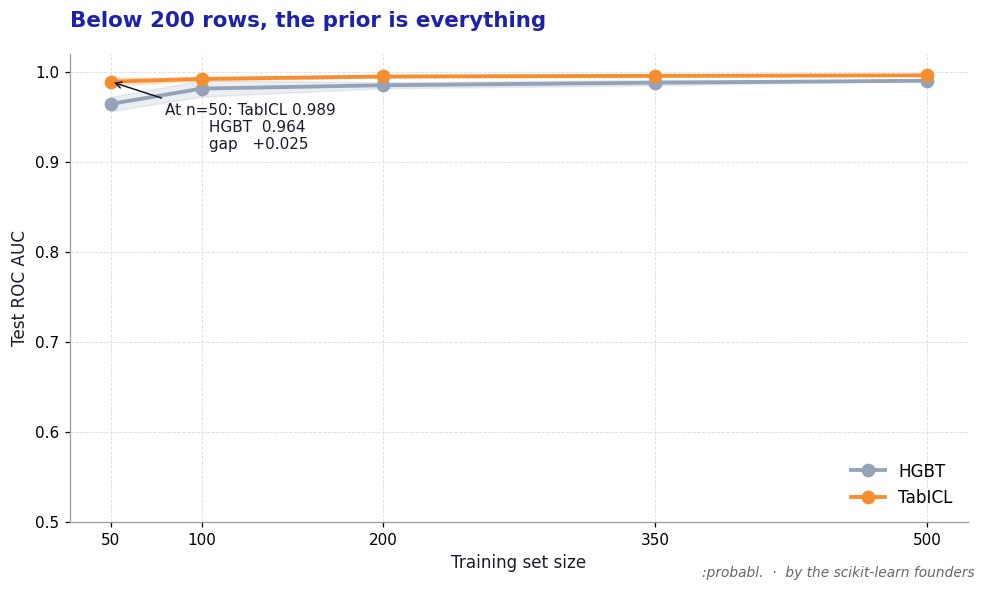

In [5]:
# Learning curves with ±1 std bands
summary = (
    results_df.groupby(["model", "size"])["auc"]
    .agg(["mean", "std"])
    .reset_index()
)

fig, ax = plt.subplots(figsize=(9, 5.4))

color_map = {"HGBT": GRAY, "TabICL": ORANGE}
for model_name in ["HGBT", "TabICL"]:
    sub = summary[summary["model"] == model_name].sort_values("size")
    color = color_map[model_name]
    ax.plot(sub["size"], sub["mean"], "-o", color=color, lw=2.5, ms=8,
            label=model_name, zorder=3)
    ax.fill_between(
        sub["size"],
        sub["mean"] - sub["std"],
        sub["mean"] + sub["std"],
        color=color, alpha=0.18, zorder=2,
    )

# Annotate the gap at n=50
n50 = summary[summary["size"] == 50].set_index("model")["mean"]
gap = n50["TabICL"] - n50["HGBT"]
ax.annotate(
    f"At n=50: TabICL {n50['TabICL']:.3f}\n         HGBT  {n50['HGBT']:.3f}\n         gap   +{gap:.3f}",
    xy=(50, n50["TabICL"]),
    xytext=(80, n50["HGBT"] - 0.05),
    fontsize=10, color=DARK,
    arrowprops=dict(arrowstyle="->", color=DARK, lw=1.0),
)

ax.set_xlabel("Training set size", color=DARK, fontsize=11)
ax.set_ylabel("Test ROC AUC", color=DARK, fontsize=11)
ax.set_title(
    "Below 200 rows, the prior is everything",
    color=BLUE, fontsize=14, fontweight="bold", loc="left", pad=18,
)
ax.set_xticks(TRAIN_SIZES)
ax.set_ylim(0.5, 1.02)
ax.grid(True, color="#E0E0E0", linestyle="--", linewidth=0.6, zorder=0)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
for spine in ["bottom", "left"]:
    ax.spines[spine].set_color("#999999")
ax.legend(loc="lower right", frameon=False, fontsize=11)

fig.text(0.99, 0.02, ":probabl.  ·  by the scikit-learn founders",
         ha="right", color="#666666", fontsize=9, style="italic")

plt.tight_layout()
out = Path("recordings/final/demo5_chart.png")
out.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(out, dpi=150, bbox_inches="tight", facecolor="white")
plt.show()

## 3. Anchor the extreme: n=50 with Skore

Build `EstimatorReport` for both pipelines at the smallest training size, then `ComparisonReport`. The `summarize().frame()` call gives the metrics table; `metrics.roc()` overlays the curves.

In [6]:
# Use seed 0 sub-sample at n=50
X_50, _, y_50, _ = train_test_split(
    X_pool, y_pool, train_size=50, stratify=y_pool, random_state=0
)

pipe_hgbt_50 = make_hgbt().fit(X_50, y_50)
pipe_tabicl_50 = make_tabicl().fit(X_50, y_50)

report_hgbt = skore.EstimatorReport(
    pipe_hgbt_50, fit=False,
    X_train=X_50, y_train=y_50,
    X_test=X_test, y_test=y_test,
    pos_label=1,
)
report_tabicl = skore.EstimatorReport(
    pipe_tabicl_50, fit=False,
    X_train=X_50, y_train=y_50,
    X_test=X_test, y_test=y_test,
    pos_label=1,
)

comparison = skore.ComparisonReport(reports={
    "HGBT (n=50)": report_hgbt,
    "TabICL (n=50)": report_tabicl,
})

comparison.metrics.summarize().frame()

Output()

Estimator,HGBT (n=50),TabICL (n=50)
Metric,,
Accuracy,0.830000,0.890000
Precision,1.000000,1.000000
Recall,0.730159,0.825397
ROC AUC,0.966538,0.991849
Log loss,0.476955,0.250443
Brier score,0.138274,0.082138
Fit time (s),NaN,NaN
Predict time (s),0.021545,0.394646


In [7]:
comparison.metrics.roc()
plt.show()

Output()

In [ ]:
project = skore.Project("debray.yann/demo5-small-data", mode="hub")
project.put("hgbt-n50", report_hgbt)
project.put("tabicl-n50", report_tabicl)
print(project)
print(f"https://skore.probabl.ai/{project.name}")


Output()

Consult your report at 
]8;id=2863501;https://skore.probabl.ai/debray.yann/demo5-small-data/estimators/8785\https://skore.probabl.ai/debray.yann/demo5-small-data/estimators/8785]8;;\

Output()